In [1]:
from astropy.table import Table, vstack
from astropy.wcs import WCS
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import itertools
from astropy.modeling import models, fitting
from astropy.stats import gaussian_fwhm_to_sigma
import astropy.units as u

In [2]:
from reproject.mosaicking import find_optimal_celestial_wcs

In [17]:
def crf_footprint(flc_sub):
    hdus_sub = []
    for f in flc_sub:
        hdul = fits.open(f)
        data = hdul[1].data
        wcs = WCS(hdul[1].header)
        
        hdus_sub.append((data, wcs))
        
    wcs_out, shape = find_optimal_celestial_wcs(hdus_sub)
    coords = wcs_out.wcs.crval*u.deg
    size = (np.array(shape) + 50)*np.abs(wcs_out.wcs.cdelt).mean()*3600*u.arcsec

    return coords, size, wcs

Jul 02, 2025 2:53:22 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.pds4.Pds4TableBuilder not found - can't register
Jul 02, 2025 2:53:23 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.parquet.ParquetTableBuilder not found - can't register
Jul 02, 2025 2:53:23 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.feather.FeatherTableBuilder not found - can't register
Jul 02, 2025 2:53:23 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.gbin.GbinTableBuilder not found - can't register
Params: Max Error(Number)/arcsec=0.06199999999999999
Tuning: HEALPix k(Integer)=18
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 2.0345053E-5 of sky (HEALPix 1: 0000 0020 0000)
Assessing range of coordinates from table 2...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020

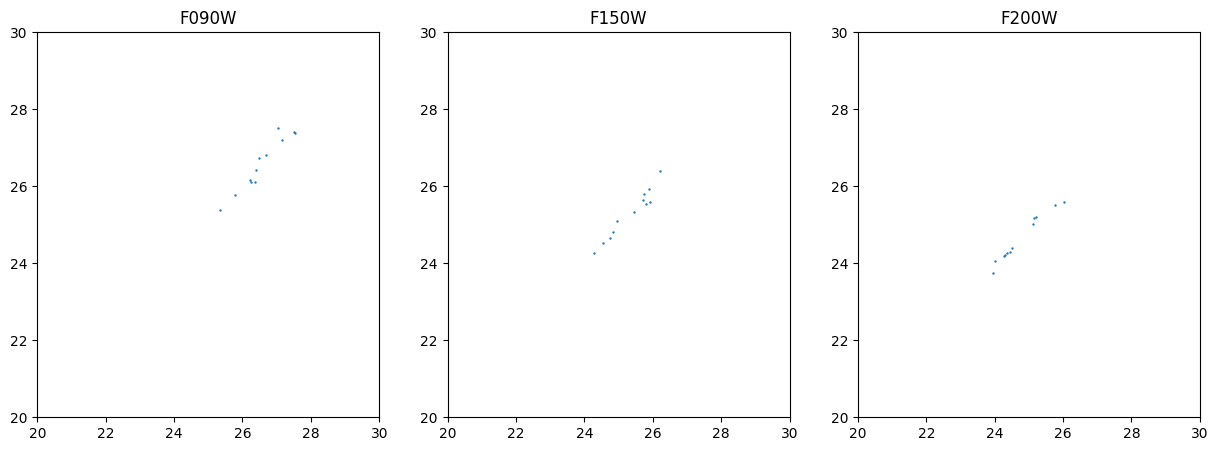

Jul 02, 2025 2:53:27 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.pds4.Pds4TableBuilder not found - can't register
Jul 02, 2025 2:53:27 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.parquet.ParquetTableBuilder not found - can't register
Jul 02, 2025 2:53:27 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.feather.FeatherTableBuilder not found - can't register
Jul 02, 2025 2:53:27 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.gbin.GbinTableBuilder not found - can't register
Params: Max Error(Number)/arcsec=0.06199999999999999
Tuning: HEALPix k(Integer)=18
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020 0000)
Assessing range of coordinates from table 2...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020

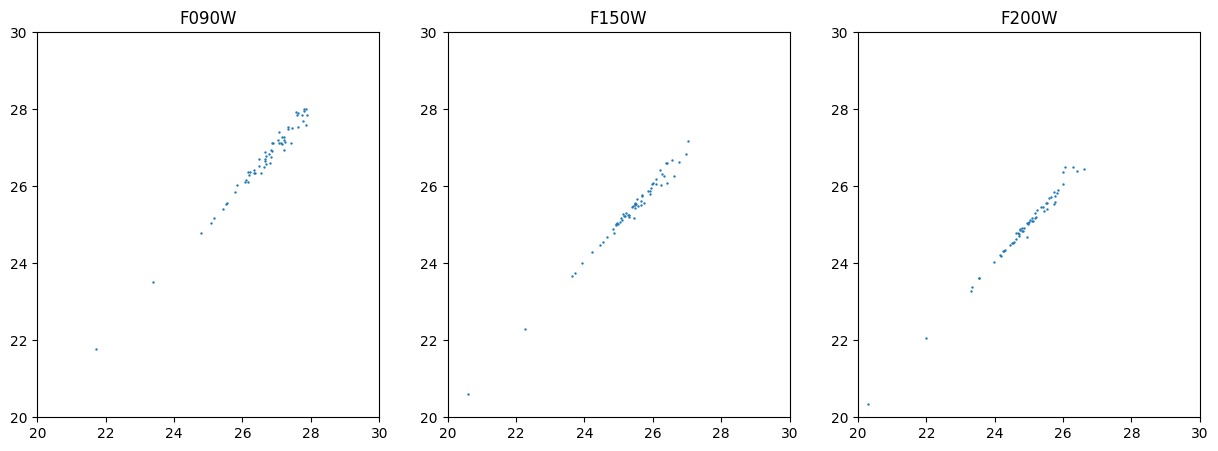

Jul 02, 2025 2:53:32 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.pds4.Pds4TableBuilder not found - can't register
Jul 02, 2025 2:53:32 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.parquet.ParquetTableBuilder not found - can't register
Jul 02, 2025 2:53:32 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.feather.FeatherTableBuilder not found - can't register
Jul 02, 2025 2:53:32 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.gbin.GbinTableBuilder not found - can't register
Params: Max Error(Number)/arcsec=0.06199999999999999
Tuning: HEALPix k(Integer)=18
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020 0000)
................................... table 2
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020 0000)
Potential match region: 4.06

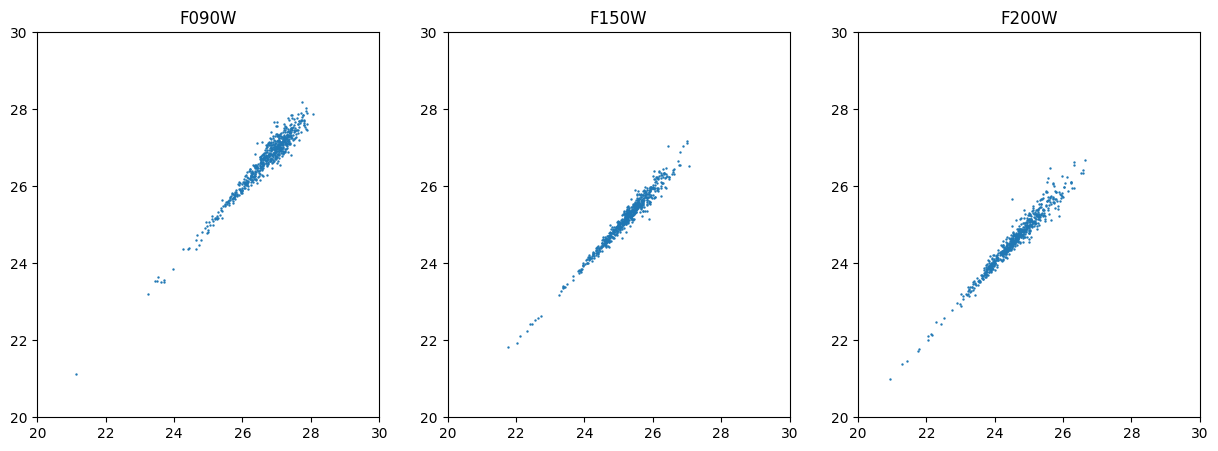

Jul 02, 2025 2:53:41 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.pds4.Pds4TableBuilder not found - can't register
Jul 02, 2025 2:53:41 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.parquet.ParquetTableBuilder not found - can't register
Jul 02, 2025 2:53:41 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.feather.FeatherTableBuilder not found - can't register
Jul 02, 2025 2:53:41 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.gbin.GbinTableBuilder not found - can't register
Params: Max Error(Number)/arcsec=0.06199999999999999
Tuning: HEALPix k(Integer)=18
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020 0000)
Assessing range of coordinates from table 2...................................
Coverage is: 2.0345053E-5 of sky (HEALPix 1: 0000 0020

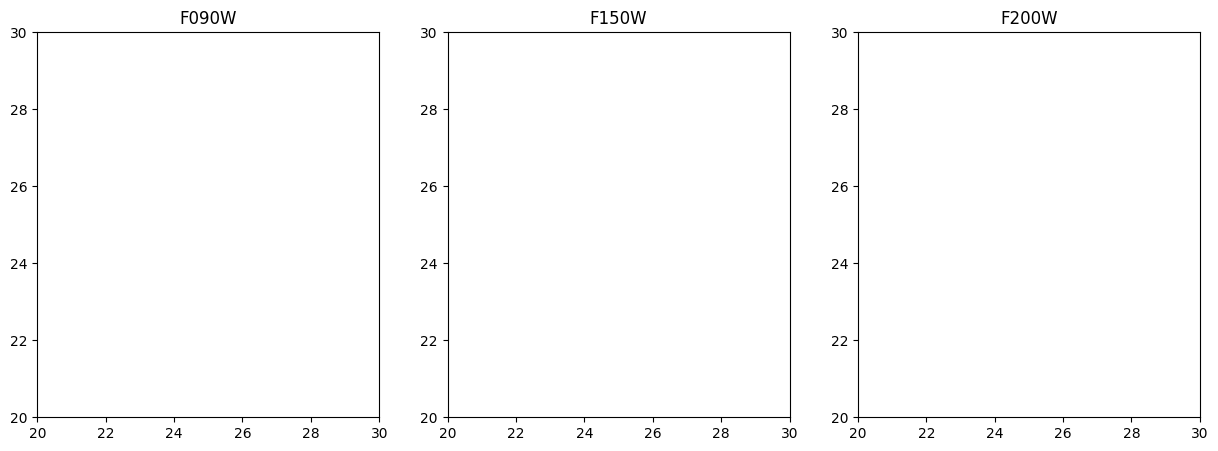

Jul 02, 2025 2:53:45 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.pds4.Pds4TableBuilder not found - can't register
Jul 02, 2025 2:53:45 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.parquet.ParquetTableBuilder not found - can't register
Jul 02, 2025 2:53:45 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.feather.FeatherTableBuilder not found - can't register
Jul 02, 2025 2:53:45 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.gbin.GbinTableBuilder not found - can't register
Params: Max Error(Number)/arcsec=0.06199999999999999
Tuning: HEALPix k(Integer)=18
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020 0000)
Assessing range of coordinates from table 2...................................
Coverage is: 2.0345053E-5 of sky (HEALPix 1: 0000 0020

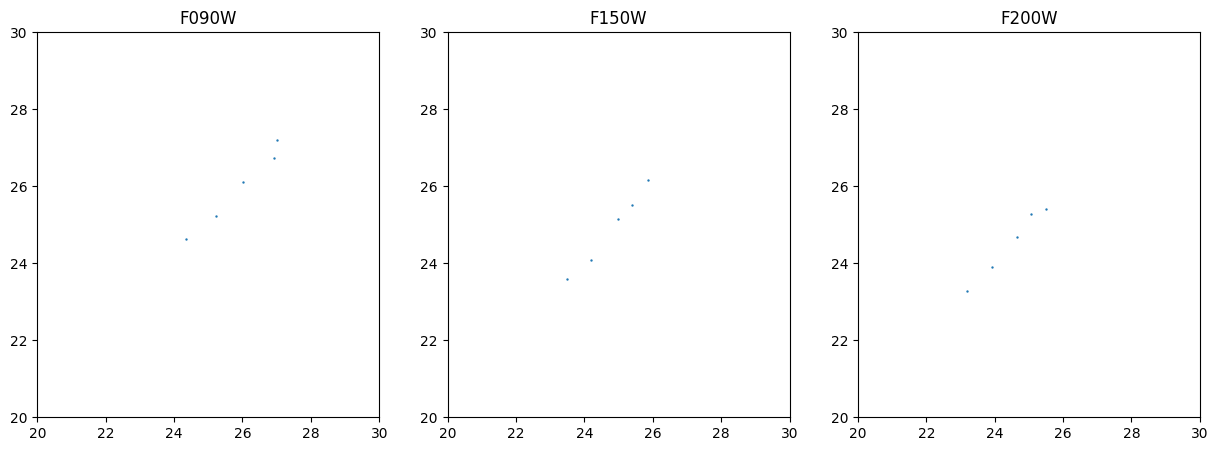

Jul 02, 2025 2:53:48 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.pds4.Pds4TableBuilder not found - can't register
Jul 02, 2025 2:53:48 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.parquet.ParquetTableBuilder not found - can't register
Jul 02, 2025 2:53:48 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.feather.FeatherTableBuilder not found - can't register
Jul 02, 2025 2:53:48 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.gbin.GbinTableBuilder not found - can't register
Params: Max Error(Number)/arcsec=0.06199999999999999
Tuning: HEALPix k(Integer)=18
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020 0000)
Assessing range of coordinates from table 2...................................
Coverage is: 2.0345053E-5 of sky (HEALPix 1: 0000 0020

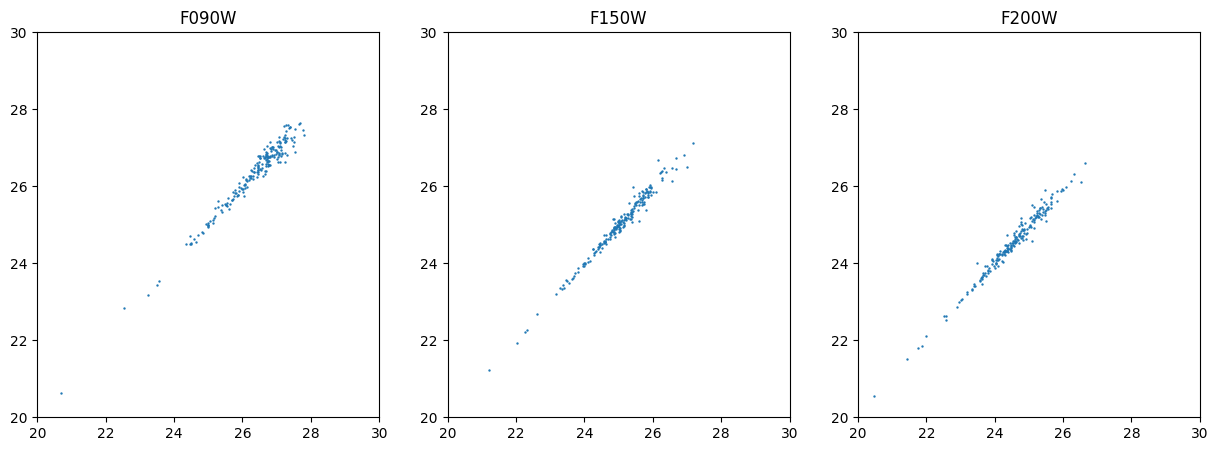

Jul 02, 2025 2:53:53 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.pds4.Pds4TableBuilder not found - can't register
Jul 02, 2025 2:53:53 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.parquet.ParquetTableBuilder not found - can't register
Jul 02, 2025 2:53:53 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.feather.FeatherTableBuilder not found - can't register
Jul 02, 2025 2:53:53 PM uk.ac.starlink.table.StarTableFactory <init>
INFO: uk.ac.starlink.gbin.GbinTableBuilder not found - can't register
Params: Max Error(Number)/arcsec=0.06199999999999999
Tuning: HEALPix k(Integer)=18
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 4.0690105E-5 of sky (HEALPix 1: 0000 0020 0000)
Assessing range of coordinates from table 2...................................
Coverage is: 2.0345053E-5 of sky (HEALPix 1: 0000 0020

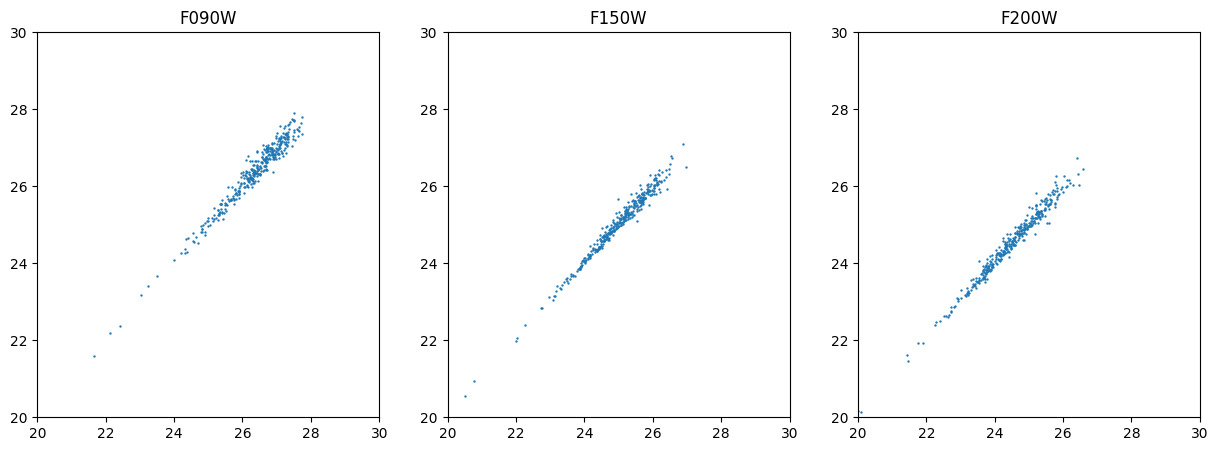

In [4]:
filt_n = 'f090w_f150w_f200w'
out_dir = f'../data/arp142/photometry/'
os.makedirs(out_dir, exist_ok=True)
fs = glob.glob(f"../data/arp142/photometry/{filt_n}*_filt.fits")
in1 = fs[0]

for f in fs[1:]:
    in2 = f
    out1 = f"{out_dir}/t1.fits"
    out2 = f"{out_dir}/t2.fits"

    out3 = f"{out_dir}/{filt_n}_photometry.fits"

    os.system(f"topcat -stilts tskymatch2 in1={in1} in2={in2} out={out1} \
                    join=1xor2 \
                 ra1=ra dec1=dec ra2=ra dec2=dec error=0.062")

    os.system(f"topcat -stilts tskymatch2 in1={in1} in2={in2} out={out2} \
             ra1=ra dec1=dec ra2=ra dec2=dec error=0.062")

    tab = Table.read(out1)
    cols = [i.split('_1')[0] for i in tab.keys()[:53]]

    col1 = tab.keys()[:53]
    col2 = tab.keys()[53:]
    tab1 = tab[tab['ext_1']==1.0][col1]
    tab2 = tab[tab['ext_2']==1.0][col2]

    tab1.rename_columns(tab1.keys(), cols)
    tab2.rename_columns(tab2.keys(), cols)

    tab3 = Table.read(out2)    
    tab3 = tab3[tab3[f'mag_vega_{filt_n[:5].upper()}_1']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[:5].upper()}_2']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[6:11].upper()}_1']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[6:11].upper()}_2']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[12:].upper()}_1']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[12:].upper()}_2']<31]

    fig, ax = plt.subplots(1,3, figsize=(15,5))
    
    x = tab3[f'mag_vega_{filt_n[:5].upper()}_1']
    y = tab3[f'mag_vega_{filt_n[:5].upper()}_2']

    ax[0].scatter(x,y,s=0.5)
    ax[0].set_title(filt_n[:5].upper())
    ax[0].set_xlim(20,30)
    ax[0].set_ylim(20,30)
    
    x = tab3[f'mag_vega_{filt_n[6:11].upper()}_1']
    y = tab3[f'mag_vega_{filt_n[6:11].upper()}_2']
    ax[1].scatter(x,y,s=0.5)
    ax[1].set_xlim(20,30)
    ax[1].set_ylim(20,30)
    ax[1].set_title(filt_n[6:11].upper())
    
    x = tab3[f'mag_vega_{filt_n[12:].upper()}_1']
    y = tab3[f'mag_vega_{filt_n[12:].upper()}_2']
    ax[2].scatter(x,y,s=0.5)
    ax[2].set_xlim(20,30)
    ax[2].set_ylim(20,30)
    ax[2].set_title(filt_n[12:].upper())
    plt.show()
    
    rows = []
    for i in range(len(tab3)):
        row = tab3[i:i+1]
        if row[f'mag_err_{filt_n[12:].upper()}_1']<=row[f'mag_err_{filt_n[12:].upper()}_2']:
            row.rename_columns(col1,cols)
        else:
            row.rename_columns(col2,cols)
        rows.append(row[cols])

    if len(rows)>0:
        tab4 = vstack(rows)
        tab5 = vstack([tab1,tab2,tab4])
    else:
        tab5 = vstack([tab1,tab2])

    tab5.write(out3, overwrite=True) 
    in1 = out3

In [ ]:
filt_n = 'f140m_f212n'
out_dir = f'../data/m82/photometry/'
os.makedirs(out_dir, exist_ok=True)
fs = glob.glob(f"../data/m82/photometry/{filt_n}*_filt.fits")
in1 = fs[0]

for f in fs[1:]:
    in2 = f
    out1 = f"{out_dir}/t1.fits"
    out2 = f"{out_dir}/t2.fits"

    out3 = f"{out_dir}/{filt_n}_photometry.fits"

    os.system(f"topcat -stilts tskymatch2 in1={in1} in2={in2} out={out1} \
                    join=1xor2 \
                 ra1=ra dec1=dec ra2=ra dec2=dec error=0.062")

    os.system(f"topcat -stilts tskymatch2 in1={in1} in2={in2} out={out2} \
             ra1=ra dec1=dec ra2=ra dec2=dec error=0.062")

    tab = Table.read(out1)
    cols = [i.split('_1')[0] for i in tab.keys()[:40]]

    col1 = tab.keys()[:40]
    col2 = tab.keys()[40:]
    tab1 = tab[tab['ext_1']==1.0][col1]
    tab2 = tab[tab['ext_2']==1.0][col2]

    tab1.rename_columns(tab1.keys(), cols)
    tab2.rename_columns(tab2.keys(), cols)

    tab3 = Table.read(out2)    
    tab3 = tab3[tab3[f'mag_vega_{filt_n[:5].upper()}_1']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[:5].upper()}_2']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[6:11].upper()}_1']<31]
    tab3 = tab3[tab3[f'mag_vega_{filt_n[6:11].upper()}_2']<31]

    fig, ax = plt.subplots(1,2, figsize=(10,5))
    
    x = tab3[f'mag_vega_{filt_n[:5].upper()}_1']
    y = tab3[f'mag_vega_{filt_n[:5].upper()}_2']

    ax[0].scatter(x,y,s=0.5)
    ax[0].set_title(filt_n[:5].upper())
    ax[0].set_xlim(20,30)
    ax[0].set_ylim(20,30)
    
    x = tab3[f'mag_vega_{filt_n[6:11].upper()}_1']
    y = tab3[f'mag_vega_{filt_n[6:11].upper()}_2']
    ax[1].scatter(x,y,s=0.5)
    ax[1].set_xlim(20,30)
    ax[1].set_ylim(20,30)
    ax[1].set_title(filt_n[6:11].upper())
    
    plt.show()
    
    rows = []
    for i in range(len(tab3)):
        row = tab3[i:i+1]
        if row[f'mag_err_{filt_n[6:11].upper()}_1']<=row[f'mag_err_{filt_n[6:11].upper()}_2']:
            row.rename_columns(col1,cols)
        else:
            row.rename_columns(col2,cols)
        rows.append(row[cols])

    if len(rows)>0:
        tab4 = vstack(rows)
        tab5 = vstack([tab1,tab2,tab4])
    else:
        tab5 = vstack([tab1,tab2])

    tab5.write(out3, overwrite=True) 
    in1 = out3

In [ ]:
filters = ['F140M','F212N']
for filt in itertools.combinations(filters,2):

    in1  = f"../data/m82/photometry/{filt[0]}/{filt[0]}_photometry.fits"
    in2  = f"../data/m82/photometry/{filt[1]}/{filt[1]}_photometry.fits"
    out1 = f"../data/m82/photometry/t1.fits"
    out2 = f"../data/m82/photometry/t2.fits"

    out  = f"../data/m82/photometry/{filt[0].lower()}_{filt[1].lower()}.fits"

    os.system(f"""topcat -stilts tpipe in={in1} \
                cmd='select "mag_err_{filt[0]}<=0.2"' \
                out={out1}""")

    os.system(f"""topcat -stilts tpipe in={in2} \
                cmd='select "mag_err_{filt[1]}<=0.2"' \
                out={out2}""")

    os.system(f"topcat -stilts tskymatch2 in1={out1} in2={out2} out={out} \
                  ra1=ra dec1=dec ra2=ra dec2=dec error=0.06")

In [ ]:
filters = ['F115W', 'F150W', 'F200W']

in1 = f"../data/stage2/output/{filters[0]}_photometry.fits"
in2 = f"../data/stage2/output/{filters[1].lower()}_{filters[2].lower()}.fits"

out = f"../data/stage2/output/{filters[0].lower()}_{filters[1].lower()}_{filters[2].lower()}.fits"

os.system(f"topcat -stilts tskymatch2 in1={in1} in2={in2} out={out} \
              ra1=ra dec1=dec ra2=ra_1 dec2=dec_1 error=0.06")
